In [1]:
import os
import json
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH = r"C:\Users\User\Music\FYP\data\raw"

In [2]:
def load_all_json_files(data_path):
    """
    Load all JSON files.
    Filename format: {month}_{day}_{vehicle_id}.json
    e.g. 1_10_6.json = Month 1, Day 10, Vehicle 6
    """
    all_files = glob.glob(os.path.join(data_path, "*.json"))
    print(f"📂 Found {len(all_files)} JSON files\n")

    records_list = []
    skipped = []

    for file_path in sorted(all_files):
        filename = os.path.splitext(os.path.basename(file_path))[0]

        # Parse filename: month_day_vehicle
        parts = filename.split("_")
        if len(parts) != 3:
            print(f"  ⚠️  Unexpected filename format: {filename} — skipping")
            skipped.append(filename)
            continue

        try:
            month      = int(parts[0])
            day        = int(parts[1])
            vehicle_id = int(parts[2])
        except ValueError:
            print(f"  ⚠️  Could not parse filename: {filename} — skipping")
            skipped.append(filename)
            continue

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                raw = json.load(f)

            # Flatten nested list structure: [[[ records ]]] → [records]
            records = []
            if isinstance(raw, list):
                for level1 in raw:
                    if isinstance(level1, list):
                        for level2 in level1:
                            if isinstance(level2, list):
                                records.extend(level2)
                            elif isinstance(level2, dict):
                                records.append(level2)
                    elif isinstance(level1, dict):
                        records.append(level1)

            if records:
                df = pd.DataFrame(records)
                df['file_month']  = month
                df['file_day']    = day
                df['vehicle_id']  = vehicle_id
                df['source_file'] = filename
                records_list.append(df)
                print(f"  ✅ {filename}.json → Vehicle {vehicle_id:>3} | "
                      f"Month {month} Day {day:>2} | {len(df):,} records")
            else:
                print(f"  ⚠️  {filename}: No records parsed")
                skipped.append(filename)

        except Exception as e:
            print(f"  ❌ {filename}: Failed — {e}")
            skipped.append(filename)

    if not records_list:
        print("❌ No data loaded. Check your DATA_PATH.")
        return None

    master_df = pd.concat(records_list, ignore_index=True)

    print(f"\n{'='*55}")
    print(f"✅ LOAD COMPLETE")
    print(f"   Total records   : {len(master_df):,}")
    print(f"   Unique vehicles : {master_df['vehicle_id'].nunique()}")
    print(f"   Months present  : {sorted(master_df['file_month'].unique())}")
    print(f"   Files skipped   : {len(skipped)}")
    print(f"{'='*55}")

    return master_df

master_raw_df = load_all_json_files(DATA_PATH)

📂 Found 900 JSON files

  ✅ 1_10_0.json → Vehicle   0 | Month 1 Day 10 | 28 records
  ⚠️  1_10_1: No records parsed
  ⚠️  1_10_2: No records parsed
  ⚠️  1_10_3: No records parsed
  ✅ 1_10_4.json → Vehicle   4 | Month 1 Day 10 | 25 records
  ✅ 1_10_5.json → Vehicle   5 | Month 1 Day 10 | 326 records
  ⚠️  1_10_6: No records parsed
  ✅ 1_10_7.json → Vehicle   7 | Month 1 Day 10 | 208 records
  ✅ 1_10_8.json → Vehicle   8 | Month 1 Day 10 | 1,030 records
  ✅ 1_10_9.json → Vehicle   9 | Month 1 Day 10 | 779 records
  ✅ 1_11_0.json → Vehicle   0 | Month 1 Day 11 | 71 records
  ⚠️  1_11_1: No records parsed
  ⚠️  1_11_2: No records parsed
  ⚠️  1_11_3: No records parsed
  ✅ 1_11_4.json → Vehicle   4 | Month 1 Day 11 | 24 records
  ✅ 1_11_5.json → Vehicle   5 | Month 1 Day 11 | 81 records
  ⚠️  1_11_6: No records parsed
  ✅ 1_11_7.json → Vehicle   7 | Month 1 Day 11 | 25 records
  ✅ 1_11_8.json → Vehicle   8 | Month 1 Day 11 | 1,032 records
  ✅ 1_11_9.json → Vehicle   9 | Month 1 Day 11 | 51

In [3]:
def audit_dataset(df):
    print("=" * 70)
    print("📊  DATASET AUDIT REPORT")
    print("=" * 70)

    # ── File coverage: which months/days do we have per vehicle? ──────
    print("\n📁  FILES PER VEHICLE (Month coverage):")
    file_summary = (df.groupby('vehicle_id')['file_month']
                      .apply(lambda x: sorted(x.unique().tolist()))
                      .reset_index()
                      .rename(columns={'file_month': 'months_present'}))
    file_counts  = df.groupby('vehicle_id')['source_file'].nunique().reset_index()
    file_counts.columns = ['vehicle_id', 'num_files']
    file_summary = file_summary.merge(file_counts, on='vehicle_id')
    print(file_summary.to_string(index=False))

    # ── Per-vehicle stats ─────────────────────────────────────────────
    print("\n📋  PER-VEHICLE RECORD STATS:")
    df['datetime_parsed'] = pd.to_datetime(df['datetime'], errors='coerce')
    df['fuel1_volume']    = pd.to_numeric(df['fuel1_volume'], errors='coerce')
    df['mileage']         = pd.to_numeric(df['mileage'], errors='coerce')

    stats = df.groupby('vehicle_id').agg(
        Records       = ('datetime', 'count'),
        Date_Start    = ('datetime_parsed', 'min'),
        Date_End      = ('datetime_parsed', 'max'),
        Duplicates    = ('datetime', lambda x: x.duplicated().sum()),
        Fuel_Min      = ('fuel1_volume', 'min'),
        Fuel_Max      = ('fuel1_volume', 'max'),
        Mileage_Start = ('mileage', 'min'),
        Mileage_End   = ('mileage', 'max'),
    ).reset_index()

    stats['Total_KM']    = (stats['Mileage_End'] - stats['Mileage_Start']).round(2)
    stats['Date_Start']  = stats['Date_Start'].dt.strftime('%Y-%m-%d')
    stats['Date_End']    = stats['Date_End'].dt.strftime('%Y-%m-%d')
    print(stats.to_string(index=False))

    # ── Monthly breakdown ─────────────────────────────────────────────
    print("\n📅  RECORDS PER MONTH:")
    monthly = df.groupby(['file_month', 'vehicle_id']).size().unstack(fill_value=0)
    monthly.index = [f"Month {m}" for m in monthly.index]
    monthly.columns = [f"V{v}" for v in monthly.columns]
    print(monthly.to_string())

    # ── Event message types ───────────────────────────────────────────
    print("\n🏷️   UNIQUE EVENT TYPES:")
    if 'event_message' in df.columns:
        event_counts = df['event_message'].value_counts()
        for evt, cnt in event_counts.items():
            print(f"   {cnt:>8,}  ×  {evt}")

    print("=" * 70)
    return stats

audit_stats = audit_dataset(master_raw_df.copy())

📊  DATASET AUDIT REPORT

📁  FILES PER VEHICLE (Month coverage):
 vehicle_id months_present  num_files
          0      [1, 5, 8]         90
          1         [5, 8]         52
          2         [5, 8]         53
          3            [8]         23
          4      [1, 5, 8]         90
          5      [1, 5, 8]         90
          6         [5, 8]         31
          7      [1, 5, 8]         83
          8      [1, 5, 8]         90
          9      [1, 5, 8]         90

📋  PER-VEHICLE RECORD STATS:
 vehicle_id  Records Date_Start   Date_End  Duplicates  Fuel_Min  Fuel_Max  Mileage_Start  Mileage_End    Total_KM
          0    12681 2024-01-01 2024-08-31         512   23.7400   66.2500     28668.7500   32748.3400   4079.5900
          1    36044 2024-05-09 2024-08-31         315    0.0000  212.9300         0.0000  127605.0780 127605.0800
          2     3469 2024-05-01 2024-08-31          66   43.5900  108.3400     48543.8200   48772.1020    228.2800
          3     2144 2024-08

In [4]:
def preprocess_master(df):
    """
    Preprocess the full master DataFrame.
    Key challenge: same vehicle appears in multiple files,
    so we deduplicate across files by (vehicle_id + datetime).
    """
    df = df.copy()
    print(f"📥 Records before cleaning : {len(df):,}")

    # 1. Parse datetime
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df = df.dropna(subset=['datetime'])

    # 2. Cast numeric columns
    numeric_cols = ['mileage', 'heading', 'speed', 'longitude',
                    'latitude', 'acc', 'fuel1_volume', 'fuel2_volume']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 3. Remove duplicates across files — same vehicle, same datetime
    before = len(df)
    df = df.drop_duplicates(subset=['vehicle_id', 'datetime'])
    print(f"🗑️  Cross-file duplicates removed : {before - len(df):,}")

    # 4. Sort by vehicle then time
    df = df.sort_values(['vehicle_id', 'datetime']).reset_index(drop=True)

    # 5. Per-vehicle derived columns
    df['time_delta_s']    = df.groupby('vehicle_id')['datetime'].diff().dt.total_seconds().fillna(0)
    df['mileage_delta_km']= df.groupby('vehicle_id')['mileage'].diff().fillna(0).clip(lower=0)
    df['fuel_delta']      = df.groupby('vehicle_id')['fuel1_volume'].diff().fillna(0)

    print(f"📤 Records after cleaning  : {len(df):,}")
    print(f"   Vehicles : {df['vehicle_id'].nunique()}")
    print(f"   Date range : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
    print(f"   Months covered : {sorted(df['file_month'].unique())}")

    return df

master_clean_df = preprocess_master(master_raw_df)
master_clean_df.head()

📥 Records before cleaning : 299,278
🗑️  Cross-file duplicates removed : 3,094
📤 Records after cleaning  : 296,184
   Vehicles : 10
   Date range : 2024-01-01 → 2024-08-31
   Months covered : [np.int64(1), np.int64(5), np.int64(8)]


,datetime,mileage,heading,speed,longitude,latitude,acc,event_message,fuel1_volume,fuel2_volume,temperature,file_month,file_day,vehicle_id,source_file,time_delta_s,mileage_delta_km,fuel_delta
0,2024-01-01 09:26:23,28668.7500,0.0000,0.0000,103.9186,1.4882,0,AP REPORT,26.1000,0.0000,0,1,1,0,1_1_0,0.0000,0.0000,0.0000
1,2024-01-01 10:27:39,28668.7500,0.0000,0.0000,103.9186,1.4882,0,AP REPORT,26.2200,0.0000,0,1,1,0,1_1_0,3676.0000,0.0000,0.1200
2,2024-01-01 11:28:56,28668.7500,0.0000,0.0000,103.9186,1.4882,0,AP REPORT,26.4700,0.0000,0,1,1,0,1_1_0,3677.0000,0.0000,0.2500
3,2024-01-01 12:30:13,28668.7500,0.0000,0.0000,103.9186,1.4882,0,AP REPORT,26.2200,0.0000,0,1,1,0,1_1_0,3677.0000,0.0000,-0.2500
4,2024-01-01 13:31:30,28668.7500,0.0000,0.0000,103.9186,1.4882,0,AP REPORT,26.3500,0.0000,0,1,1,0,1_1_0,3677.0000,0.0000,0.1300


In [5]:
def segment_trips(df, vehicle_id, max_gap_minutes=30):
    """
    Segment records into individual trips using IGNITION ON/OFF events.
    Falls back to time-gap segmentation if ignition events are sparse.
    """
    df = df.copy()
    df['trip_id'] = None

    ignition_events = df[df['event_message'].isin(['IGNITION ON', 'IGNITION OFF'])]

    if len(ignition_events) >= 2:
        trip_counter = 0
        in_trip = False
        trip_start_idx = None

        for idx, row in df.iterrows():
            if row['event_message'] == 'IGNITION ON' and not in_trip:
                in_trip = True
                trip_start_idx = idx
                trip_counter += 1
            elif row['event_message'] == 'IGNITION OFF' and in_trip:
                in_trip = False
                df.loc[trip_start_idx:idx, 'trip_id'] = f"V{vehicle_id}_T{trip_counter:04d}"

        # Close any unclosed trip at end of data
        if in_trip and trip_start_idx is not None:
            df.loc[trip_start_idx:, 'trip_id'] = f"V{vehicle_id}_T{trip_counter:04d}"

        method = "IGNITION events"

    else:
        # Fallback: segment by time gap
        trip_counter = 1
        gap_threshold = max_gap_minutes * 60
        current_trip = f"V{vehicle_id}_T{trip_counter:04d}"
        trip_ids = []

        for i in range(len(df)):
            if i > 0 and df.iloc[i]['time_delta_s'] > gap_threshold:
                trip_counter += 1
                current_trip = f"V{vehicle_id}_T{trip_counter:04d}"
            trip_ids.append(current_trip)

        df['trip_id'] = trip_ids
        method = f"time-gap (>{max_gap_minutes} min)"

    trip_count = df['trip_id'].nunique()
    print(f"  🚗 Vehicle {vehicle_id}: {trip_count} trips segmented via {method}")
    return df


# ── Apply to master_clean_df (grouped by vehicle_id) ──────────────────
print("🚗 Segmenting trips...\n")

segmented_parts = []
for vid, group in master_clean_df.groupby('vehicle_id'):
    group_reset = group.reset_index(drop=True)
    segmented = segment_trips(group_reset, vid)
    segmented_parts.append(segmented)

# Combine back into one master DataFrame
master_df = pd.concat(segmented_parts, ignore_index=True)

print(f"\n✅ Segmentation complete:")
print(f"   Total records : {len(master_df):,}")
print(f"   Total trips   : {master_df['trip_id'].nunique():,}")
print(f"   Vehicles      : {master_df['vehicle_id'].nunique()}")
print(f"   Trips with no ignition assignment (parked/idle): "
      f"{master_df['trip_id'].isna().sum():,} records")

🚗 Segmenting trips...

  🚗 Vehicle 0: 502 trips segmented via IGNITION events
  🚗 Vehicle 1: 172 trips segmented via IGNITION events
  🚗 Vehicle 2: 54 trips segmented via IGNITION events
  🚗 Vehicle 3: 33 trips segmented via IGNITION events
  🚗 Vehicle 4: 64 trips segmented via IGNITION events
  🚗 Vehicle 5: 262 trips segmented via IGNITION events
  🚗 Vehicle 6: 696 trips segmented via time-gap (>30 min)
  🚗 Vehicle 7: 132 trips segmented via IGNITION events
  🚗 Vehicle 8: 52 trips segmented via IGNITION events
  🚗 Vehicle 9: 335 trips segmented via IGNITION events

✅ Segmentation complete:
   Total records : 296,184
   Total trips   : 2,302
   Vehicles      : 10
   Trips with no ignition assignment (parked/idle): 145,648 records


In [6]:
def engineer_trip_features(master_df):
    """
    Compute per-trip features: kinematic, temporal, fuel, and spatial.
    Includes extended features for better anomaly detection signal.
    """
    print("⚙️  Engineering features per trip...\n")
    trip_features = []

    for trip_id, trip in master_df.groupby('trip_id'):
        if len(trip) < 2:
            continue  # skip single-record trips

        trip = trip.sort_values('datetime')

        # ── Basic info ────────────────────────────────────────────────
        vehicle_id   = trip['vehicle_id'].iloc[0]
        start_time   = trip['datetime'].iloc[0]
        end_time     = trip['datetime'].iloc[-1]
        duration_s   = (end_time - start_time).total_seconds()
        duration_min = duration_s / 60

        # ── Temporal features ─────────────────────────────────────────
        start_hour    = start_time.hour
        day_of_week   = start_time.dayofweek  # 0=Mon, 6=Sun
        is_weekend    = int(day_of_week >= 5)
        is_afterhours = int(start_hour < 6 or start_hour >= 22)
        is_night      = int(start_hour >= 22 or start_hour < 5)
        is_earlyam    = int(5 <= start_hour < 7)
        is_lunchtime  = int(11 <= start_hour < 14)

        # ── Kinematic features ────────────────────────────────────────
        speeds     = trip['speed'].dropna()
        speed_mean = speeds.mean()
        speed_max  = speeds.max()
        speed_std  = speeds.std() if len(speeds) > 1 else 0

        # Coefficient of variation — erratic driving
        speed_cv = (speed_std / speed_mean) if speed_mean > 0 else 0

        # % of time spent above speed thresholds
        speed_above_80_ratio  = float((speeds > 80).sum()  / len(speeds)) if len(speeds) > 0 else 0
        speed_above_100_ratio = float((speeds > 100).sum() / len(speeds)) if len(speeds) > 0 else 0

        # Acceleration events
        speed_vals = trip['speed'].values
        time_vals  = trip['time_delta_s'].values
        accel      = np.where(time_vals[1:] > 0,
                              np.diff(speed_vals) / time_vals[1:], 0)
        harsh_accel_count = int(np.sum(accel >  3.0))
        harsh_brake_count = int(np.sum(accel < -3.0))
        decel_events      = int(np.sum(accel < -2.0))   # softer decel, more sensitive

        # Idle time
        idle_mask   = (trip['speed'] == 0) & (trip['acc'] == 1)
        idle_time_s = trip.loc[idle_mask, 'time_delta_s'].sum()
        idle_ratio  = idle_time_s / duration_s if duration_s > 0 else 0

        # ── Spatial / distance features ───────────────────────────────
        total_km     = trip['mileage_delta_km'].sum()
        stop_count   = int(((trip['speed'] == 0) & (trip['speed'].shift(1) > 0)).sum())
        km_per_hour  = (total_km / (duration_s / 3600)) if duration_s > 0 else 0
        stops_per_km = (stop_count / total_km) if total_km > 0.5 else 0

        # Heading / route consistency
        if 'heading' in trip.columns:
            headings        = trip['heading'].dropna()
            heading_std     = headings.std() if len(headings) > 1 else 0
            heading_changes = int((headings.diff().abs() > 45).sum())
        else:
            heading_std     = 0
            heading_changes = 0

        # ── Fuel features ─────────────────────────────────────────────
        fuel_start    = trip['fuel1_volume'].iloc[0]
        fuel_end      = trip['fuel1_volume'].iloc[-1]
        fuel_consumed = fuel_start - fuel_end   # positive = consumed

        fuel_per_100km  = (fuel_consumed / total_km * 100) if total_km > 0.5 else np.nan
        fuel_drop_rate  = (fuel_consumed / duration_min) if duration_min > 0 else 0

        # Stationary fuel drop features
        stationary               = trip[trip['speed'] == 0]
        fuel_drops_stationary    = stationary['fuel_delta'].clip(upper=0).sum()
        suspicious_fuel_drop     = float(abs(fuel_drops_stationary))

        # ── Compile feature row ───────────────────────────────────────
        trip_features.append({
            # Identifiers (dropped before model training)
            'trip_id':                  trip_id,
            'vehicle_id':               vehicle_id,
            'start_time':               start_time,
            'end_time':                 end_time,

            # Temporal
            'start_hour':               start_hour,
            'day_of_week':              day_of_week,
            'is_weekend':               is_weekend,
            'is_afterhours':            is_afterhours,       # ← dropped in model training (direct label)
            'is_night':                 is_night,
            'is_earlyam':               is_earlyam,
            'is_lunchtime':             is_lunchtime,

            # Kinematic
            'speed_mean':               round(speed_mean, 2),
            'speed_max':                round(speed_max, 2),
            'speed_std':                round(speed_std, 4),
            'speed_cv':                 round(speed_cv, 4),
            'speed_above_80_ratio':     round(speed_above_80_ratio, 4),
            'speed_above_100_ratio':    round(speed_above_100_ratio, 4),
            'harsh_accel_count':        harsh_accel_count,
            'harsh_brake_count':        harsh_brake_count,
            'decel_events':             decel_events,
            'idle_time_s':              round(idle_time_s, 2),
            'idle_ratio':               round(idle_ratio, 4),

            # Spatial
            'total_km':                 round(total_km, 4),
            'stop_count':               stop_count,
            'km_per_hour':              round(km_per_hour, 4),
            'stops_per_km':             round(stops_per_km, 4),
            'heading_std':              round(heading_std, 4),
            'heading_changes':          heading_changes,

            # Fuel
            'fuel_start_L':             round(fuel_start, 2),
            'fuel_end_L':               round(fuel_end, 2),
            'fuel_consumed_L':          round(fuel_consumed, 2),
            'fuel_per_100km':           round(fuel_per_100km, 2) if not np.isnan(fuel_per_100km) else np.nan,
            'fuel_drop_rate':           round(fuel_drop_rate, 4),
            'suspicious_fuel_drop_L':   round(suspicious_fuel_drop, 2),

            # Duration (dropped in model training — direct label)
            'duration_min':             round(duration_min, 2),
        })

    features_df = pd.DataFrame(trip_features)
    print(f"✅ Feature matrix: {features_df.shape[0]} trips × {features_df.shape[1]} features")
    return features_df

features_df = engineer_trip_features(master_df)
features_df.head(10)

⚙️  Engineering features per trip...

✅ Feature matrix: 1638 trips × 35 features


,trip_id,vehicle_id,start_time,end_time,start_hour,day_of_week,is_weekend,is_afterhours,is_night,is_earlyam,is_lunchtime,speed_mean,speed_max,speed_std,speed_cv,speed_above_80_ratio,speed_above_100_ratio,harsh_accel_count,harsh_brake_count,decel_events,idle_time_s,idle_ratio,total_km,stop_count,km_per_hour,stops_per_km,heading_std,heading_changes,fuel_start_L,fuel_end_L,fuel_consumed_L,fuel_per_100km,fuel_drop_rate,suspicious_fuel_drop_L,duration_min
0,V0_T0001,0,2024-01-02 08:32:04,2024-01-02 08:32:17,8,1,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,96.0000,7.3846,0.0000,0,0.0000,0.0000,86.9741,1,26.3500,26.4700,-0.1200,NaN,-0.5538,0.0000,0.2200
1,V0_T0002,0,2024-01-02 09:36:53,2024-01-02 09:46:55,9,1,0,0,0,0,0,17.8800,48.1000,14.3160,0.8005,0.0000,0.0000,0,0,0,336.0000,0.5581,3.7210,2,22.2518,0.5375,72.8888,6,26.3500,24.4800,1.8700,50.2600,0.1864,0.0000,10.0300
2,V0_T0003,0,2024-01-02 09:50:26,2024-01-02 10:03:58,9,1,0,0,0,0,0,11.5600,53.6500,15.0160,1.2987,0.0000,0.0000,0,0,0,636.0000,0.7833,2.1480,3,9.5232,1.3966,132.8767,8,37.2800,41.2600,-3.9800,-185.2900,-0.2941,0.6300,13.5300
3,V0_T0004,0,2024-01-02 10:36:38,2024-01-02 10:48:35,10,1,0,0,0,0,0,4.5100,14.8000,5.6101,1.2441,0.0000,0.0000,0,0,0,2301.0000,3.2092,0.6020,3,3.0226,4.9834,124.4701,8,41.2600,41.0100,0.2500,41.5300,0.0209,0.5000,11.9500
4,V0_T0005,0,2024-01-02 11:55:39,2024-01-02 12:26:42,11,1,0,0,0,0,1,7.4000,37.0000,11.7635,1.5897,0.0000,0.0000,0,0,0,1742.0000,0.9351,2.6890,3,5.1961,1.1157,91.3561,14,40.8900,40.2700,0.6200,23.0600,0.0200,1.8700,31.0500
5,V0_T0006,0,2024-01-02 13:48:43,2024-01-02 14:07:58,13,1,0,0,0,0,1,10.3500,46.2500,13.5000,1.3048,0.0000,0.0000,0,0,0,1740.0000,1.5065,3.4100,2,10.6286,0.5865,120.4086,10,40.0200,39.5200,0.5000,14.6600,0.0260,1.1200,19.2500
6,V0_T0007,0,2024-01-02 14:38:47,2024-01-02 14:58:38,14,1,0,0,0,0,0,10.5600,46.2500,13.7631,1.3030,0.0000,0.0000,0,0,0,2547.0000,2.1385,3.1100,4,9.4005,1.2862,96.6415,11,39.2700,38.6500,0.6200,19.9400,0.0312,1.6200,19.8500
7,V0_T0008,0,2024-01-02 15:24:21,2024-01-02 15:24:47,15,1,0,0,0,0,0,0.9200,1.8500,1.3081,1.4142,0.0000,0.0000,0,0,0,1543.0000,59.3462,0.0000,0,0.0000,0.0000,43.1335,1,38.1600,38.0300,0.1300,NaN,0.3000,0.4900,0.4300
8,V0_T0009,0,2024-01-02 16:20:58,2024-01-02 16:34:45,16,1,0,0,0,0,0,17.1700,38.8500,12.5646,0.7319,0.0000,0.0000,0,0,0,3491.0000,4.2213,5.2200,3,22.7231,0.5747,124.3517,10,38.6500,36.9100,1.7400,33.3300,0.1262,0.6200,13.7800
9,V0_T0010,0,2024-01-03 08:36:18,2024-01-03 09:03:01,8,2,0,0,0,0,0,13.4100,42.5500,14.4018,1.0738,0.0000,0.0000,0,0,0,3394.0000,2.1173,5.3300,5,11.9701,0.9381,106.2364,18,36.2900,35.7900,0.5000,9.3800,0.0187,1.6100,26.7200


In [7]:
def label_anomalies(features_df, drop_flags=True):
    """
    Generate weak supervision labels using rule-based heuristics.

    ⚠️ METHODOLOGICAL NOTE:
    Labels are derived from the exact same features used in model training.
    This means model performance measures rule-replication accuracy, not
    true anomaly detection accuracy against ground-truth incidents.

    When drop_flags=True (default), both the flag columns AND the raw
    features that directly define those flags are removed, so the saved
    ML dataset contains only indirect behavioural features.
    """
    df = features_df.copy()

    # Compute quantiles BEFORE any flag creation
    fuel_q_hi     = df['fuel_per_100km'].quantile(0.95)
    duration_q_hi = df['duration_min'].quantile(0.95)

    df['flag_fuel_theft']    = (df['suspicious_fuel_drop_L'] > 3.0).astype(int)
    df['flag_aggressive']    = ((df['harsh_accel_count'] + df['harsh_brake_count'] > 5) | (df['speed_max'] > 120)).astype(int)
    df['flag_afterhours']    = df['is_afterhours'].astype(int)
    df['flag_abnormal_fuel'] = (df['fuel_per_100km'] > fuel_q_hi).astype(int)
    df['flag_long_trip']     = (df['duration_min'] > duration_q_hi).astype(int)

    flag_cols = [c for c in df.columns if c.startswith('flag_')]
    df['anomaly_score'] = df[flag_cols].sum(axis=1)
    df['is_anomaly']    = (df['anomaly_score'] >= 1).astype(int)

    if drop_flags:
        # Drop the flag columns and anomaly_score
        df = df.drop(columns=flag_cols + ['anomaly_score'])

        # Also drop the raw features that directly define the labels —
        # leaving these in would let the model trivially re-learn the rules
        LABEL_DEFINING_FEATURES = [
            'suspicious_fuel_drop_L',  # → flag_fuel_theft
            'speed_max',               # → flag_aggressive
            'is_afterhours',           # → flag_afterhours
            'fuel_per_100km',          # → flag_abnormal_fuel
            'duration_min',            # → flag_long_trip
            'harsh_accel_count',       # → flag_aggressive
            'harsh_brake_count',       # → flag_aggressive
            'fuel_start_L',            # raw fuel (leakage risk)
            'fuel_end_L',              # raw fuel (leakage risk)
            'fuel_consumed_L',         # raw fuel (leakage risk)
        ]
        df = df.drop(columns=LABEL_DEFINING_FEATURES, errors='ignore')

    return df

# Version WITH flags — for EDA and the visualise_dataset() call below
labelled_df_with_flags = label_anomalies(features_df, drop_flags=False)

# Version WITHOUT flags and without circular features — for ML training
labelled_df = label_anomalies(features_df, drop_flags=True)


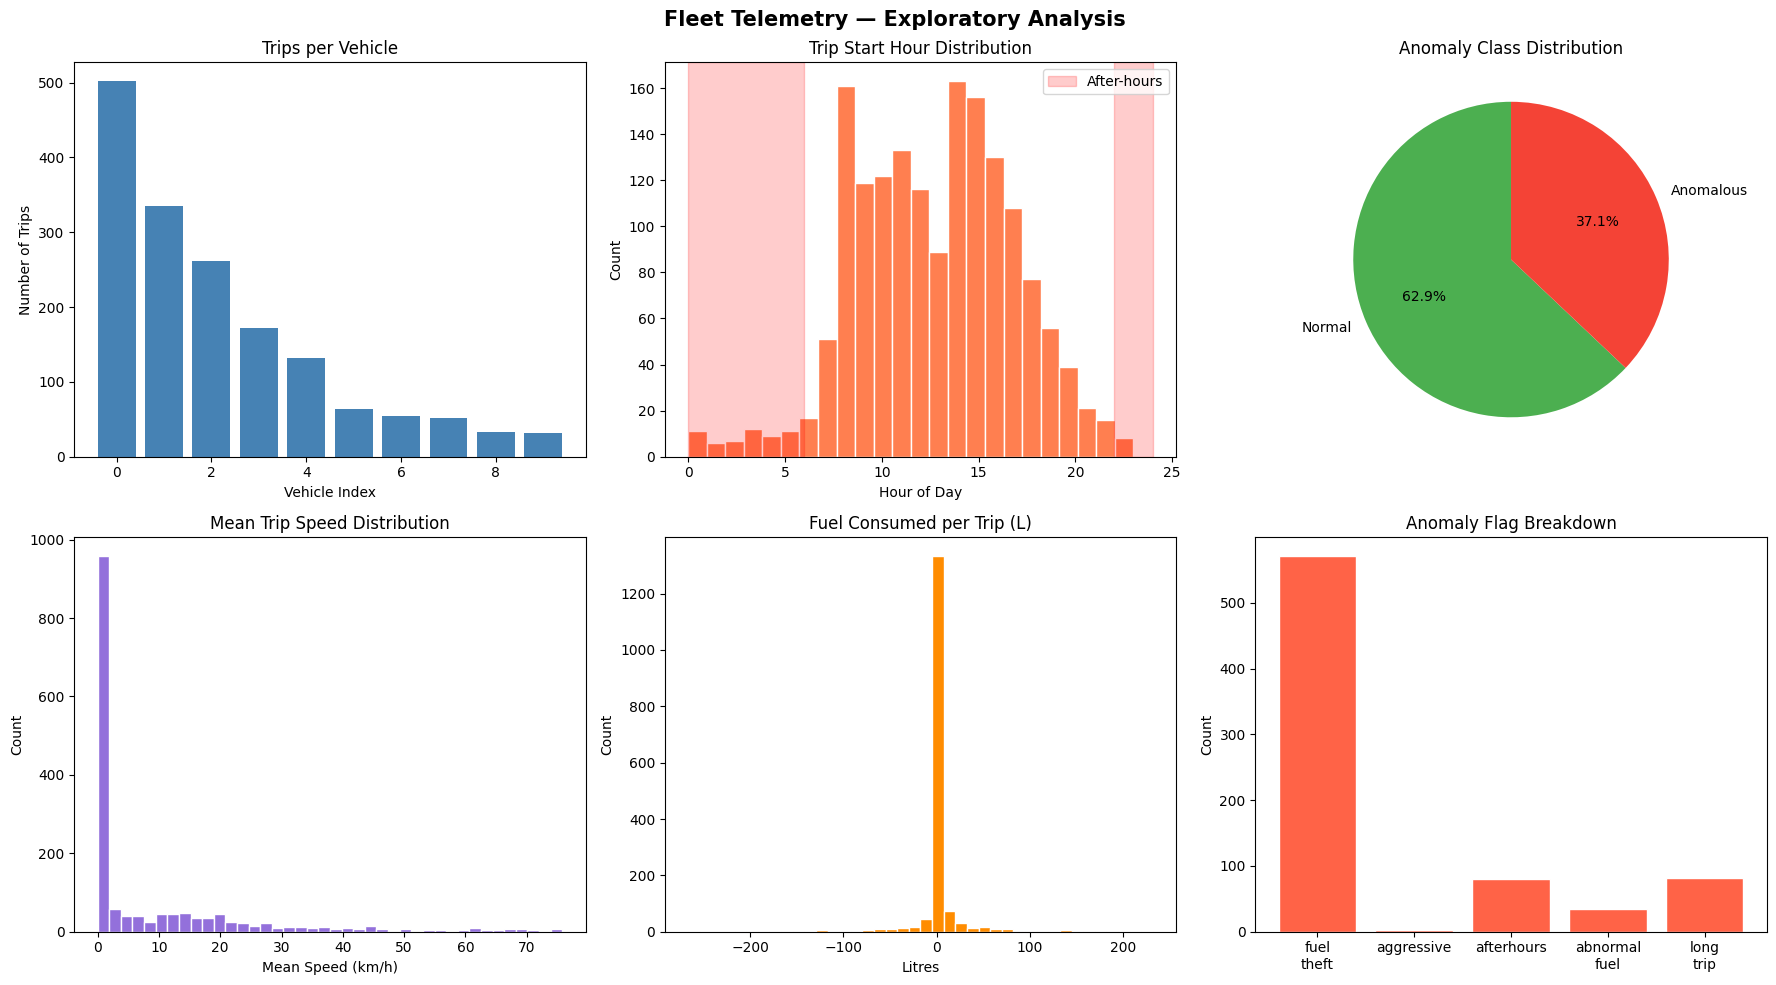

✅ Plot saved to: C:\Users\User\Music\FYP\data\raw\fleet_eda.png


In [8]:
def visualise_dataset(labelled_df, master_df):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Fleet Telemetry — Exploratory Analysis', fontsize=15, fontweight='bold')

    # 1. Trips per vehicle
    trips_per_veh = labelled_df.groupby('vehicle_id').size().sort_values(ascending=False)
    axes[0,0].bar(range(len(trips_per_veh)), trips_per_veh.values, color='steelblue')
    axes[0,0].set_title('Trips per Vehicle')
    axes[0,0].set_xlabel('Vehicle Index')
    axes[0,0].set_ylabel('Number of Trips')

    # 2. Trip start hour distribution
    axes[0,1].hist(labelled_df['start_hour'], bins=24, color='coral', edgecolor='white')
    axes[0,1].set_title('Trip Start Hour Distribution')
    axes[0,1].set_xlabel('Hour of Day')
    axes[0,1].set_ylabel('Count')
    axes[0,1].axvspan(22, 24, alpha=0.2, color='red', label='After-hours')
    axes[0,1].axvspan(0,  6,  alpha=0.2, color='red')
    axes[0,1].legend()

    # 3. Anomaly class distribution
    counts = labelled_df['is_anomaly'].value_counts()
    axes[0,2].pie(counts.values,
                  labels=['Normal', 'Anomalous'],
                  colors=['#4CAF50', '#F44336'],
                  autopct='%1.1f%%', startangle=90)
    axes[0,2].set_title('Anomaly Class Distribution')

    # 4. Speed distribution
    axes[1,0].hist(labelled_df['speed_mean'].dropna(), bins=40, color='mediumpurple', edgecolor='white')
    axes[1,0].set_title('Mean Trip Speed Distribution')
    axes[1,0].set_xlabel('Mean Speed (km/h)')
    axes[1,0].set_ylabel('Count')

    # 5. Fuel consumed per trip
    fuel_data = labelled_df['fuel_consumed_L'].dropna()
    axes[1,1].hist(fuel_data, bins=40, color='darkorange', edgecolor='white')
    axes[1,1].set_title('Fuel Consumed per Trip (L)')
    axes[1,1].set_xlabel('Litres')
    axes[1,1].set_ylabel('Count')

    # 6. Anomaly flag breakdown
    flag_cols = [c for c in labelled_df.columns if c.startswith('flag_')]
    flag_counts = labelled_df[flag_cols].sum()
    flag_labels = [c.replace('flag_', '').replace('_', '\n') for c in flag_cols]
    axes[1,2].bar(flag_labels, flag_counts.values, color='tomato', edgecolor='white')
    axes[1,2].set_title('Anomaly Flag Breakdown')
    axes[1,2].set_ylabel('Count')

    plt.tight_layout()

    # ── Save to same folder as your data, works locally & on Colab ───
    save_dir = DATA_PATH  # reuses the path you defined in Cell 1
    save_path = os.path.join(save_dir, 'fleet_eda.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot saved to: {save_path}")

# Pass the version containing flag columns to the visualisation function
visualise_dataset(labelled_df_with_flags, master_df)


In [9]:
import os

SAVE_DIR = r"C:\Users\User\Music\FYP\data\processed"

master_csv_path   = os.path.join(SAVE_DIR, 'master_telemetry.csv')
labelled_csv_path = os.path.join(SAVE_DIR, 'trip_features_labelled.csv')

master_df.to_csv(master_csv_path, index=False)
labelled_df.to_csv(labelled_csv_path, index=False)

print("✅ Saved:")
print(f"   master_telemetry.csv       → {len(master_df):,} records  |  {master_csv_path}")
print(f"   trip_features_labelled.csv → {len(labelled_df):,} trips   |  {labelled_csv_path}")
print(f"\n📌 Next step: use trip_features_labelled.csv to train your ML model!")


✅ Saved:
   master_telemetry.csv       → 296,184 records  |  C:\Users\User\Music\FYP\data\processed\master_telemetry.csv
   trip_features_labelled.csv → 1,638 trips   |  C:\Users\User\Music\FYP\data\processed\trip_features_labelled.csv

📌 Next step: use trip_features_labelled.csv to train your ML model!
